# Coupled two-node mean-field brain network analysis

In this Notebook, the coupled two-node system is analyzed to understand how the mean-field firing heterogeneity affects its stability and synchronization ability.

### Objectives

1. Analyze how mean-field neuronal firing heterogeneity affects the network stability and synchronization.
2. Analyze how coupling between nodes affects the network stability and synchronization.

### Model simplications

For this analysis, the following simplest model analysis scenarios are considered:
1. both nodes and their sub-populations will have same heterogeneity para i.e., $\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2 = \sigma$
2. both nodes will have same heterogeneity paras but differentiate between sub-populations: $\sigma_x^1 = = \sigma_x^2 = \sigma_x$ where x = {e, i}
3. system will be qualitatively analyzed using time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$)
4. either have active vs. passive nodes or have both being applied the same external input (at E-populations)

### Types of measures to use

1. avg. (maximum) lyapunov exponent for network 
2. phase synchronization between two nodes at different bands
3. spectral radius and eigenvalues at the fixed points
   
### Outputs to produce

1. $\sigma^1$ vs. $\sigma^2$ (both sub-pop will have same $\sigma$ but changed between nodes)
2. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop but differentiated between sub-pops)
3. K vs. $\sigma$ (both nodes and sub-pop will have same $\sigma$)
4. K vs. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop)
5. K vs. $\sigma^1$ vs. $\sigma^2$ (both sub-pops will have same $\sigma$ values but changed between nodes)
6. spectral radius maps: change K (or $\sigma$) for given $\sigma$ (or K) | change K (or $\sigma_x$) for given $\sigma_x$ (or K)
7. Jacobian evaluation with above simplified modeling assumptions to identify the eigen values
8. time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$, K)


In [1]:
import os
import json
import time
import random
import pickle
import datetime
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from tqdm import tqdm

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
# Setting save dir paths
root_dir = "./sv_coupled_model_m"

save_str = datetime.datetime(2023, 11, 22)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

save_dir = os.path.join(root_dir, sub_dir)

print(f"Creating dir to save results:: {save_dir}")
os.makedirs(save_dir, exist_ok = True)

Creating dir to save results:: ./sv_coupled_model_m/exp-2023-11-22


In [3]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T']
time_ = np.arange(0, T)

In [4]:
# setting init values
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

In [5]:
t_start = 200
t_end = params['T']

## Scenario 01 - assume the $\sigma_x^l = \sigma$ for $x \in \{e, i\}$ and $l = 1, 2$
In this scenario, we analyze how the change in heterogeneity as a global parameter to both nodes and subpopulations are affecting the system stability and synchronization

In [6]:
# saving to separate sub-dir
scene_sub_dir = 's_01'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [7]:
# setting the constant value
params['i_e1'] = 0.25 / params['gamma']

# setting the variables
sig_min = 2.5; sig_max = 17.5; sig_steps = 10
eval_sigma = sig_min + np.arange(0, sig_steps) / sig_steps * (sig_max - sig_min)

k_min = 0; k_max = 1; k_steps = 20
eval_k = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

In [8]:
# lyapunov exponenet response maps K vs. sigma

file_name = f"lyap_ie_{params['i_e1']:.3f}"

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)
        
else:
    lyap_mats = {
                    'n1_mean': np.zeros((k_steps, sig_steps)),
                    'n2_mean': np.zeros((k_steps, sig_steps)),
                    'n1_max': np.zeros((k_steps, sig_steps)),
                    'n2_max': np.zeros((k_steps, sig_steps))
                }
    
    for k1, k in enumerate(eval_k):
        params['K'] = k
        
        tic = time.time()
        for s1, sigma in enumerate(eval_sigma):
            params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for j in range(n_trials):
                diff_1 = np.abs(np.diff(u[j, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for j in range(n_trials):
                diff_2 = np.abs(np.diff(u[j, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][k1, s1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][k1, s1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][k1, s1] = lyapunov_1.max()
            lyap_mats['n2_max'][k1, s1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing k value --> Execution time: {toc - tic :.3f}s')
        
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$K$', 'xlabel': r'$\sigma$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_k,
                        var2_arr = eval_sigma,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_k, 
                                                  var2_arr = eval_sigma, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )
thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

finishing k value --> Execution time: 67.628s
finishing k value --> Execution time: 67.529s
finishing k value --> Execution time: 67.598s
finishing k value --> Execution time: 67.568s
finishing k value --> Execution time: 67.634s
finishing k value --> Execution time: 67.576s
finishing k value --> Execution time: 67.608s
finishing k value --> Execution time: 67.602s
finishing k value --> Execution time: 67.540s


KeyboardInterrupt: 

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent

spec_rad = np.zeros((k_steps, sig_steps))
spec_cent = np.zeros((k_steps, sig_steps))
x = np.arange(-50, 50, 0.01)

for k1, K in enumerate(eval_k):
    params['K'] = K 
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}"

    tic = time.time()
    for s1, sigma in enumerate(eval_sigma):
        params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma
        
        while True:
            fp_dict = calc_fixed_points(
                                        minval=minval,
                                        maxval=maxval,
                                        grid_res=1000,
                                        n_init=100,
                                        cal_grad=False,
                                        **params
            )
        
            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[k1, s1] = rad_
        spec_cent[k1, s1] = center_
        
        lyap_val = thresh_node1_mean[k1, s1]

        if lyap_val == 1 or lyap_val == 0:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma$" + f' = {sigma:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if rad_unstable and rad_stable:
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    elif (rad_unstable is None) and rad_stable:
        rad_ = max(spec_rad[k1, :])
        center_ = spec_cent[k1, np.argmax(spec_rad[k1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[k1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[k1, :], bins = 100, color='red',alpha=0.25, density=True)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma, spec_rad[k1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize = 8)
    ax[1].set_xlabel(r'$\sigma$'); ax[1].set_ylabel(r'$\Gamma$') 
    
    if (rad_unstable) and (rad_stable):
        ax[1].axhline(y=rad_, color='k', linestyle='--')
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'Unstable', color='red', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma[sig_steps // 2], y = rad_ // 2, s = 'Stable', color='green', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma[sig_steps // 2], y = rad_, s = f'{rad_:.3f}', color='k', fontsize=16)
        
    elif (rad_unstable is None) and (rad_stable):
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
        
    else:
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'No stable region', color='red', fontsize=16, animated = True)
    
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma$ vs.  $K$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma, eval_k, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma, eval_k, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma$'); plt.ylabel(r'$K$')
plt.xticks(eval_sigma); plt.yticks(eval_k)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"ie_{params['i_e1']}_resmap.png"))
plt.show()

In [ ]:
# ts analysis and trajectories
params['sig_e1'] = 4.4; params['sig_i1'] = 16.5; params['sig_e2'] = 7.8; params['sig_i2'] = 16.5
params['K'] = 0.2

In [ ]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

In [ ]:
avg_lyap = plot_ts(
                    u = u,
                    t_arr = time_,
                    t1 = t_start,
                    t2 = T,
                    fig_size = (30, 15),
                    if_zoom=True,
                    zoom_t=[0, 100, 0, 100],
                    if_save=False,
                    save_dir=save_dir,
                    image_name=f"ts_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
                    **params
                )

fp_dict = calc_fixed_points(
                                minval = minval,
                                maxval = maxval,
                                grid_res = 1000,
                                n_init = 100,
                                cal_grad = False,
                                **params
                            )

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
    
    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])
    
    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1
    
    del u_, fe1, fe2, fi1, fi2
    
eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

In [ ]:
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

In [ ]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr1 = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T-1, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (32, 16),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

In [ ]:
freq_arr, wt_matr2 = wavelet_analysis(
                                     signals = ue2, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T-1, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (32, 16),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

In [ ]:
window_size = 200
step_window = 50

kuramoto_order = []

for t in range(t_start, T - window_size, step_window):
    ue = np.mean(u[:, 0, t : t + window_size], axis=0) + np.mean(u[:, 2, t : t + window_size], axis=0)
    ui = np.mean(u[:, 1, t : t + window_size], axis=0) + np.mean(u[:, 3, t : t + window_size], axis=0)
    real_kur = ue - np.mean(ue)
    img_kur = ui - np.mean(ui)

    kuramoto_order.append(np.mean(np.abs(real_kur + 1j * img_kur)))

In [ ]:
kuramoto_order = np.array(kuramoto_order)
norm_kuramoto = (kuramoto_order - np.mean(kuramoto_order)) / np.mean(kuramoto_order)

plt.figure(figsize=(20, 10))
plt.subplot(2, 1, 1)
plt.plot(time_[:-t_start], ue1[t_start:], 'r')
plt.plot(time_[:-t_start], ue2[t_start:], 'k')

plt.subplot(2, 1, 2)
plt.plot(time_[0:-t_start - window_size:step_window], norm_kuramoto, 'k')

In [ ]:
psi_1_args = np.argmax(np.abs(wt_matr1), axis=0)
psi_2_args = np.argmax(np.abs(wt_matr2), axis=0)

In [ ]:
psi_1 = np.array([np.unwrap(np.angle(wt_matr1[x, :])) for x in psi_1_args])
psi_2 = np.array([np.unwrap(np.angle(wt_matr2[x, :])) for x in psi_2_args])

np.abs(np.mean((np.max(np.abs(wt_matr1)) * np.exp(1j * psi_1) / (np.max(np.abs(wt_matr2)) * np.exp(1j * psi_2)))))

## Scenario 02 - assume the $\sigma_e^l = \sigma_e$ and for $\sigma_i^l = \sigma_i$ $l = 1, 2$

In [ ]:
# saving to separate sub-dir
scene_sub_dir = 's_02'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [ ]:
# setting constant values
params['K'] = 0.2
params['i_e1'] = 0.25 / params['gamma']

# setting variables
sige_min = 2.5; sige_max = 17.5; sige_steps = 10
sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 10

eval_sigma_e = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

In [ ]:
# lyapunov exponenet response maps sigma_e vs. sigma_i

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sige_steps, sigi_steps)),
                    'n2_mean': np.zeros((sige_steps, sigi_steps)),
                    'n1_max': np.zeros((sige_steps, sigi_steps)),
                    'n2_max': np.zeros((sige_steps, sigi_steps))
                }

    for e1, sigma_e in enumerate(eval_sigma_e):
        params['sig_e1'] = params['sig_e2'] = sigma_e
        tic = time.time()
        for i1, sigma_i in enumerate(eval_sigma_i):
            params['sig_i1'] = params['sig_i2'] = sigma_i
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][e1, i1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][e1, i1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][e1, i1] = lyapunov_1.max()
            lyap_mats['n2_max'][e1, i1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma_e$', 'xlabel': r'$\sigma_i$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_e,
                        var2_arr = eval_sigma_i,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_e, 
                                                  var2_arr = eval_sigma_i, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )
thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sige_steps, sigi_steps))
spec_cent = np.zeros((sige_steps, sigi_steps))

x = np.arange(-50, 50, 0.01)

for e1, sig_e in enumerate(eval_sigma_e):
    params['sig_e1'] = params['sig_e2'] = sig_e
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sige_{params['sig_e1']:.3f}"

    tic = time.time()
    for i1, sig_i in enumerate(eval_sigma_i):
        params['sig_i1'] = params['sig_i2'] = sig_i
        
        while True:
            fp_dict = calc_fixed_points(
                                        minval=minval,
                                        maxval=maxval,
                                        grid_res=1000,
                                        n_init=100,
                                        cal_grad=False,
                                        **params
            )
        
            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[e1, i1] = rad_
        spec_cent[e1, i1] = center_
        
        lyap_val = thresh_node1_mean[e1, i1]
        
        if lyap_val == 1:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1 or lyap_val == 0:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma_e$ = ' + f"{params['sig_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma_i$" + f' = {sig_i:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (rad_unstable) and (rad_stable):
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    elif (rad_unstable is None) and (rad_stable):
        rad_ = max(spec_rad[e1, :])  
        center_ = spec_cent[e1, np.argmax(spec_rad[e1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[e1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[e1, :], bins = 100, color='red',alpha=0.25, density=True)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma_i, spec_rad[e1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize = 8)
    ax[1].set_xlabel(r'$\sigma_i$'); ax[1].set_ylabel(r'$\Gamma$') 
    
    if rad_unstable and rad_stable:
        ax[1].axhline(y=rad_unstable, color='k', linestyle='--')
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'Unstable', color='red', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = rad_ // 2, s = 'Stable', color='green', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = rad_unstable, s = f'{rad_unstable:.3f}', color='k', fontsize=16)
        
    elif (rad_unstable is None) and rad_stable:
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
        
    else:
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'No stable region', color='red', fontsize=16, animated = True)
    
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma_e$ vs.  $\sigma_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_e, eval_sigma_i, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma_e, eval_sigma_i, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma_i$'); plt.ylabel(r'$\sigma_e$')
plt.xticks(eval_sigma_i); plt.yticks(eval_sigma_e)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_resmap.png"))
plt.show()

In [ ]:
# ts analysis and trajectories
params['sig_e1'] =  params['sig_e2'] = 7
params['sig_i1'] =params['sig_i2'] = 16

In [ ]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

In [ ]:
avg_lyap = plot_ts(
                    u = u,
                    t_arr = time_,
                    t1 = t_start,
                    t2 = T,
                    fig_size = (30, 15),
                    if_zoom=True,
                    zoom_t=[1000, 1100, 0, 100],
                    if_save=False,
                    save_dir=save_dir,
                    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
                    **params
                )

fp_dict = calc_fixed_points(
                                minval = minval,
                                maxval = maxval,
                                grid_res = 1000,
                                n_init = 100,
                                cal_grad = False,
                                **params
                            )

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
    
    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])
    
    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1
    
    del u_, fe1, fe2, fi1, fi2
    
eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

In [ ]:
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

In [ ]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T - t_start, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (40, 15),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

## Scenario 03 - assume the $\sigma_x^1 = \sigma^1$ and for $\sigma_x^2 = \sigma^2$ $x = \{e, i\}$

In [ ]:
# saving to separate sub-dir
scene_sub_dir = 's_03'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [ ]:
# setting constant values
params['K'] = 0.0
params['i_e1'] = 0.25 / params['gamma']

# setting variables
sig1_min = 2.5; sig1_max = 17.5; sig1_steps = 10
sig2_min = 2.5; sig2_max = 17.5; sig2_steps = 10

eval_sigma_1 = sig1_min + np.arange(0, sig1_steps) / sig1_steps * (sig1_max - sig1_min)
eval_sigma_2 = sig2_min + np.arange(0, sig2_steps) / sig2_steps * (sig2_max - sig2_min)

In [ ]:
# lyapunov exponenet response maps sigma_1 vs. sigma_2

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sig1_steps, sig2_steps)),
                    'n2_mean': np.zeros((sig1_steps, sig2_steps)),
                    'n1_max': np.zeros((sig1_steps, sig2_steps)),
                    'n2_max': np.zeros((sig1_steps, sig2_steps))
                }

    for s1, sigma_1 in enumerate(eval_sigma_1):
        params['sig_e1'] = params['sig_i1'] = sigma_1
        tic = time.time()
        for s2, sigma_2 in enumerate(eval_sigma_2):
            params['sig_e2'] = params['sig_i2'] = sigma_2
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][s1, s2] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][s1, s2] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][s1, s2] = lyapunov_1.max()
            lyap_mats['n2_max'][s1, s2] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma^1$', 'xlabel': r'$\sigma^2$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_1,
                        var2_arr = eval_sigma_2,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_1, 
                                                  var2_arr = eval_sigma_2, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )

thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sig1_steps, sig2_steps))
spec_cent = np.zeros((sig1_steps, sig2_steps))

x = np.arange(-50, 50, 0.01)

for s1, sig_1 in enumerate(eval_sigma_1):
    params['sig_e1'] = params['sig_i1'] = sig_1
    rad_stable = []; rad_unstable = []
    cent_stable = []; cent_unstable = []
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig2_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig2_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sige_{params['sig_e1']:.3f}"

    tic = time.time()
    for s2, sig_2 in enumerate(eval_sigma_2):
        params['sig_e2'] = params['sig_i2'] = sig_2
        
        while True:
            fp_dict = calc_fixed_points(
                    minval=minval,
                    maxval=maxval,
                    grid_res=1000,
                    n_init=100,
                    cal_grad=False,
                    **params
                )

            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[s1, s2] = rad_
        spec_cent[s1, s2] = center_
        
        lyap_val = thresh_node1_mean[s1, s2]
        
        if lyap_val == 1 or lyap_val == 0:
            rad_unstable.append(rad_)
            cent_unstable.append(center_)
        
        elif lyap_val == -1:
            rad_stable.append(rad_)
            cent_stable.append(center_)
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma^1$ = ' + f"{params['sig_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma^2$" + f' = {sig_2:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (len(rad_unstable) != 0) and (len(rad_stable) != 0):
        cent_unstable = cent_unstable[np.argmin(np.array(rad_unstable))]
        cent_stable = cent_stable[np.argmax(np.array(rad_stable))]
        
        rad_unstable = min(rad_unstable)
        rad_stable = max(rad_stable)
        
        rad_ = (rad_unstable + rad_stable) / 2
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')

    elif (len(rad_unstable) == 0) and (len(rad_stable) != 0):
        rad_ = max(spec_rad[s1, :])
        center_ = spec_cent[s1, np.argmax(spec_rad[s1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[s1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[s1, :], bins = 100, color='red',alpha=0.25)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma_2, spec_rad[s1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize=8)
    ax[1].set_xlabel(r'$\sigma^2$'); ax[1].set_ylabel(r'$\Gamma$')
    
    if rad_unstable and rad_stable:
        ax[1].axhline(y=rad_unstable, color='k', linestyle='--')
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=(rad_unstable + max(spec_rad[s1, :])) / 2, s='Unstable', color='red',
                   fontsize=16, animated=True)
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=rad_ // 2, s='Stable', color='green', fontsize=16,
                   animated=True)
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y = rad_unstable, s = f'{rad_unstable:.3f}', color='k', fontsize=16)

    elif (len(rad_unstable) == 0) and (len(rad_stable) != 0):
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=max(spec_rad[s1, :]) // 2, s='Whole region is stable',
                   color='green', fontsize=16, animated=True)

    else:
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=max(spec_rad[s1, :]) // 2, s='No stable region', color='red',
                   fontsize=16, animated=True)
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma_e$ vs.  $\sigma_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_1, eval_sigma_2, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma_1, eval_sigma_2, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma_2$'); plt.ylabel(r'$\sigma_1$')
plt.xticks(eval_sigma_2); plt.yticks(eval_sigma_1)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_resmap.png"))
plt.show()

In [ ]:
# ts analysis and trajectories
params['sig_e2'] = params['sig_i2'] = 2.5
params['sig_e1'] = params['sig_i1'] = 14

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

In [ ]:
avg_lyap = plot_ts(
    u=u,
    t_arr=time_,
    t1=t_start,
    t2=T,
    fig_size=(30, 15),
    if_zoom=True,
    zoom_t=[1000, 1100, 0, 100],
    if_save=False,
    save_dir=save_dir,
    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
    **params
)

fp_dict = calc_fixed_points(
    minval=minval,
    maxval=maxval,
    grid_res=1000,
    n_init=100,
    cal_grad=False,
    **params
)

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])

    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1

    del u_, fe1, fe2, fi1, fi2

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

In [ ]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T - t_start, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (40, 15),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

In [ ]:
# saving to separate sub-dir
scene_sub_dir = 's_04'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [ ]:
# setting constant values
params['K'] = 0.2
params['i_e1'] = 0.25 / params['gamma']
params['sig_e1'] = params['sig_i1'] = 2.5

# setting variables
sige_min = 2.5; sige_max = 17.5; sige_steps = 10
sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 10

eval_sigma_e = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

In [ ]:
# lyapunov exponenet response maps sigma_e vs. sigma_i

if_plot_lyap = False
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}_sig1_{params['sig_i1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sige_steps, sigi_steps)),
                    'n2_mean': np.zeros((sige_steps, sigi_steps)),
                    'n1_max': np.zeros((sige_steps, sigi_steps)),
                    'n2_max': np.zeros((sige_steps, sigi_steps))
                }

    for e1, sigma_e in enumerate(eval_sigma_e):
        params['sig_e2'] = sigma_e
        tic = time.time()
        for i1, sigma_i in enumerate(eval_sigma_i):
            params['sig_i2'] = sigma_i
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][e1, i1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][e1, i1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][e1, i1] = lyapunov_1.max()
            lyap_mats['n2_max'][e1, i1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV), " + r"$\sigma^1$ = " + f"{params['sig_i1']:.3f}"  
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma^2_e$', 'xlabel': r'$\sigma^2_i$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_e,
                        var2_arr = eval_sigma_i,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_e, 
                                                  var2_arr = eval_sigma_i, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )

In [ ]:
thersh_node1 = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sige_steps, sigi_steps))
spec_cent = np.zeros((sige_steps, sigi_steps))

x = np.arange(-50, 50, 0.01)

for e1, sig_e in enumerate(eval_sigma_e):
    params['sig_e2'] = sig_e
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sig_{params['sig_e1']:.3f}_{params['sig_e2']:.3f}"

    tic = time.time()
    for i1, sig_i in enumerate(eval_sigma_i):
        params['sig_i2'] = sig_i
        
        fp_dict = calc_fixed_points(
                                    minval=minval,
                                    maxval=maxval,
                                    grid_res=1000,
                                    n_init=100,
                                    cal_grad=False,
                                    **params
        )
        
        if fp_dict['n_fps'] == 0:
            u = np.zeros((1, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            fe1 = np.max(u[0, 0, t_start:])
            fi1 = np.max(u[0, 1, t_start:])
            fe2 = np.max(u[0, 2, t_start:])
            fi2 = np.max(u[0, 3, t_start:])
            
            fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
            fp_dict['n_fps'] = 1
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[e1, i1] = rad_
        spec_cent[e1, i1] = center_
        
        lyap_val = thersh_node1[e1, i1] # thresh_mean[e1, i1]
        
        if lyap_val == 1:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1 or lyap_val == 0:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma^1$ = ' + f"{params['sig_e1']:.3f} " +  r'$\sigma^2_e$ = ' + f"{params['sig_e2']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma^2_i$" + f' = {sig_i:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (rad_unstable != None) and (rad_stable != None):
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    elif (rad_unstable == None) and (rad_stable != None):
        rad_ = spec_rad[e1, 0]  
        center_ = spec_cent[e1, 0]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    sns.distplot(spec_rad[e1, :], kde=True, bins=20, hist=False, ax=ax[1])
    _, _, bars = ax[1].hist(spec_rad[e1, :], bins = 100, color='red',alpha=0.25, density=True)
    
    if (rad_unstable != None) and (rad_stable != None):
        ax[1].axvline(x=rad_, color='k', linestyle='--')
        ax[1].set_xlabel('Spectral Radius')
        ax[1].text(x = rad_ + 0.1, y = .23, s = 'Unstable', color='red', fontsize=16, animated = True, rotation=90)
        ax[1].text(x = rad_ - 0.1, y = .23, s = 'Stable', color='green', fontsize=16, animated = True, rotation=90)
        ax[1].text(x = rad_, y = .33, s = f'{rad_:.3f}', color='k', fontsize=16)
    elif (rad_unstable == None) and (rad_stable != None):
        ax[1].text(x = min(spec_rad[e1, :]), y = .33, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
    else:
        ax[1].text(x = min(spec_rad[e1, :]), y = .33, s = 'Whole region is unstable', color='red', fontsize=16, animated = True)
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma^2_e$ vs.  $\sigma^2_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_e, eval_sigma_i, thresh_mean, cmap='gist_gray', alpha=0.8)
plt.pcolormesh(eval_sigma_e, eval_sigma_i, spec_rad, cmap='jet', alpha=0.5)
plt.xlabel(r'$\sigma^2_i$'); plt.ylabel(r'$\sigma^2_e$')
plt.xticks(eval_sigma_i); plt.yticks(eval_sigma_e)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}, " + r"$\sigma^1$ = " + f"{params['sig_i1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_sig1_{params['sig_i1']:.3f}_resmap.png"))
plt.show()

In [ ]:
# ts analysis and trajectories
params['sig_e2'] = 2.5
params['sig_i2'] = 16.0

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

In [ ]:
avg_lyap = plot_ts(
    u=u,
    t_arr=time_,
    t1=t_start,
    t2=T,
    fig_size=(30, 15),
    if_zoom=True,
    zoom_t=[1000, 1100, 0, 100],
    if_save=False,
    save_dir=save_dir,
    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
    **params
)

fp_dict = calc_fixed_points(
    minval=minval,
    maxval=maxval,
    grid_res=1000,
    n_init=100,
    cal_grad=False,
    **params
)

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])

    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1

    del u_, fe1, fe2, fi1, fi2

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

In [9]:
import os
import glob
import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 18})
%matplotlib inline

In [10]:
root_dir = 'results/synchron'
scene_sub_dir = 'scene01'

save_str = datetime.datetime(2024, 1, 23)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

save_dir = os.path.join(root_dir, scene_sub_dir, sub_dir)
file_names = glob.glob(os.path.join(save_dir, '*.pkl'))

In [11]:
K_vals = []

for file_name in file_names:
    split_vals = file_name.split('_')
    K_vals.append(float(split_vals[2]))

K_vals = np.array(K_vals)
sort_ind = np.argsort(K_vals)
file_names = np.array(file_names)[sort_ind]
print(file_names)

['results/synchron/scene01/exp-2024-1-23/results_K_-1.00_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_-0.80_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_-0.60_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_-0.40_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_-0.20_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_0.00_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_0.20_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_0.40_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_0.60_I_0.000mV.pkl'
 'results/synchron/scene01/exp-2024-1-23/results_K_0.80_I_0.000mV.pkl']


In [12]:
sig_min = 2.5; sig_max = 17.5; sig_steps = 20
eval_sigma = sig_min + np.arange(0, sig_steps) / sig_steps * (sig_max - sig_min)

True
True


True
True
True


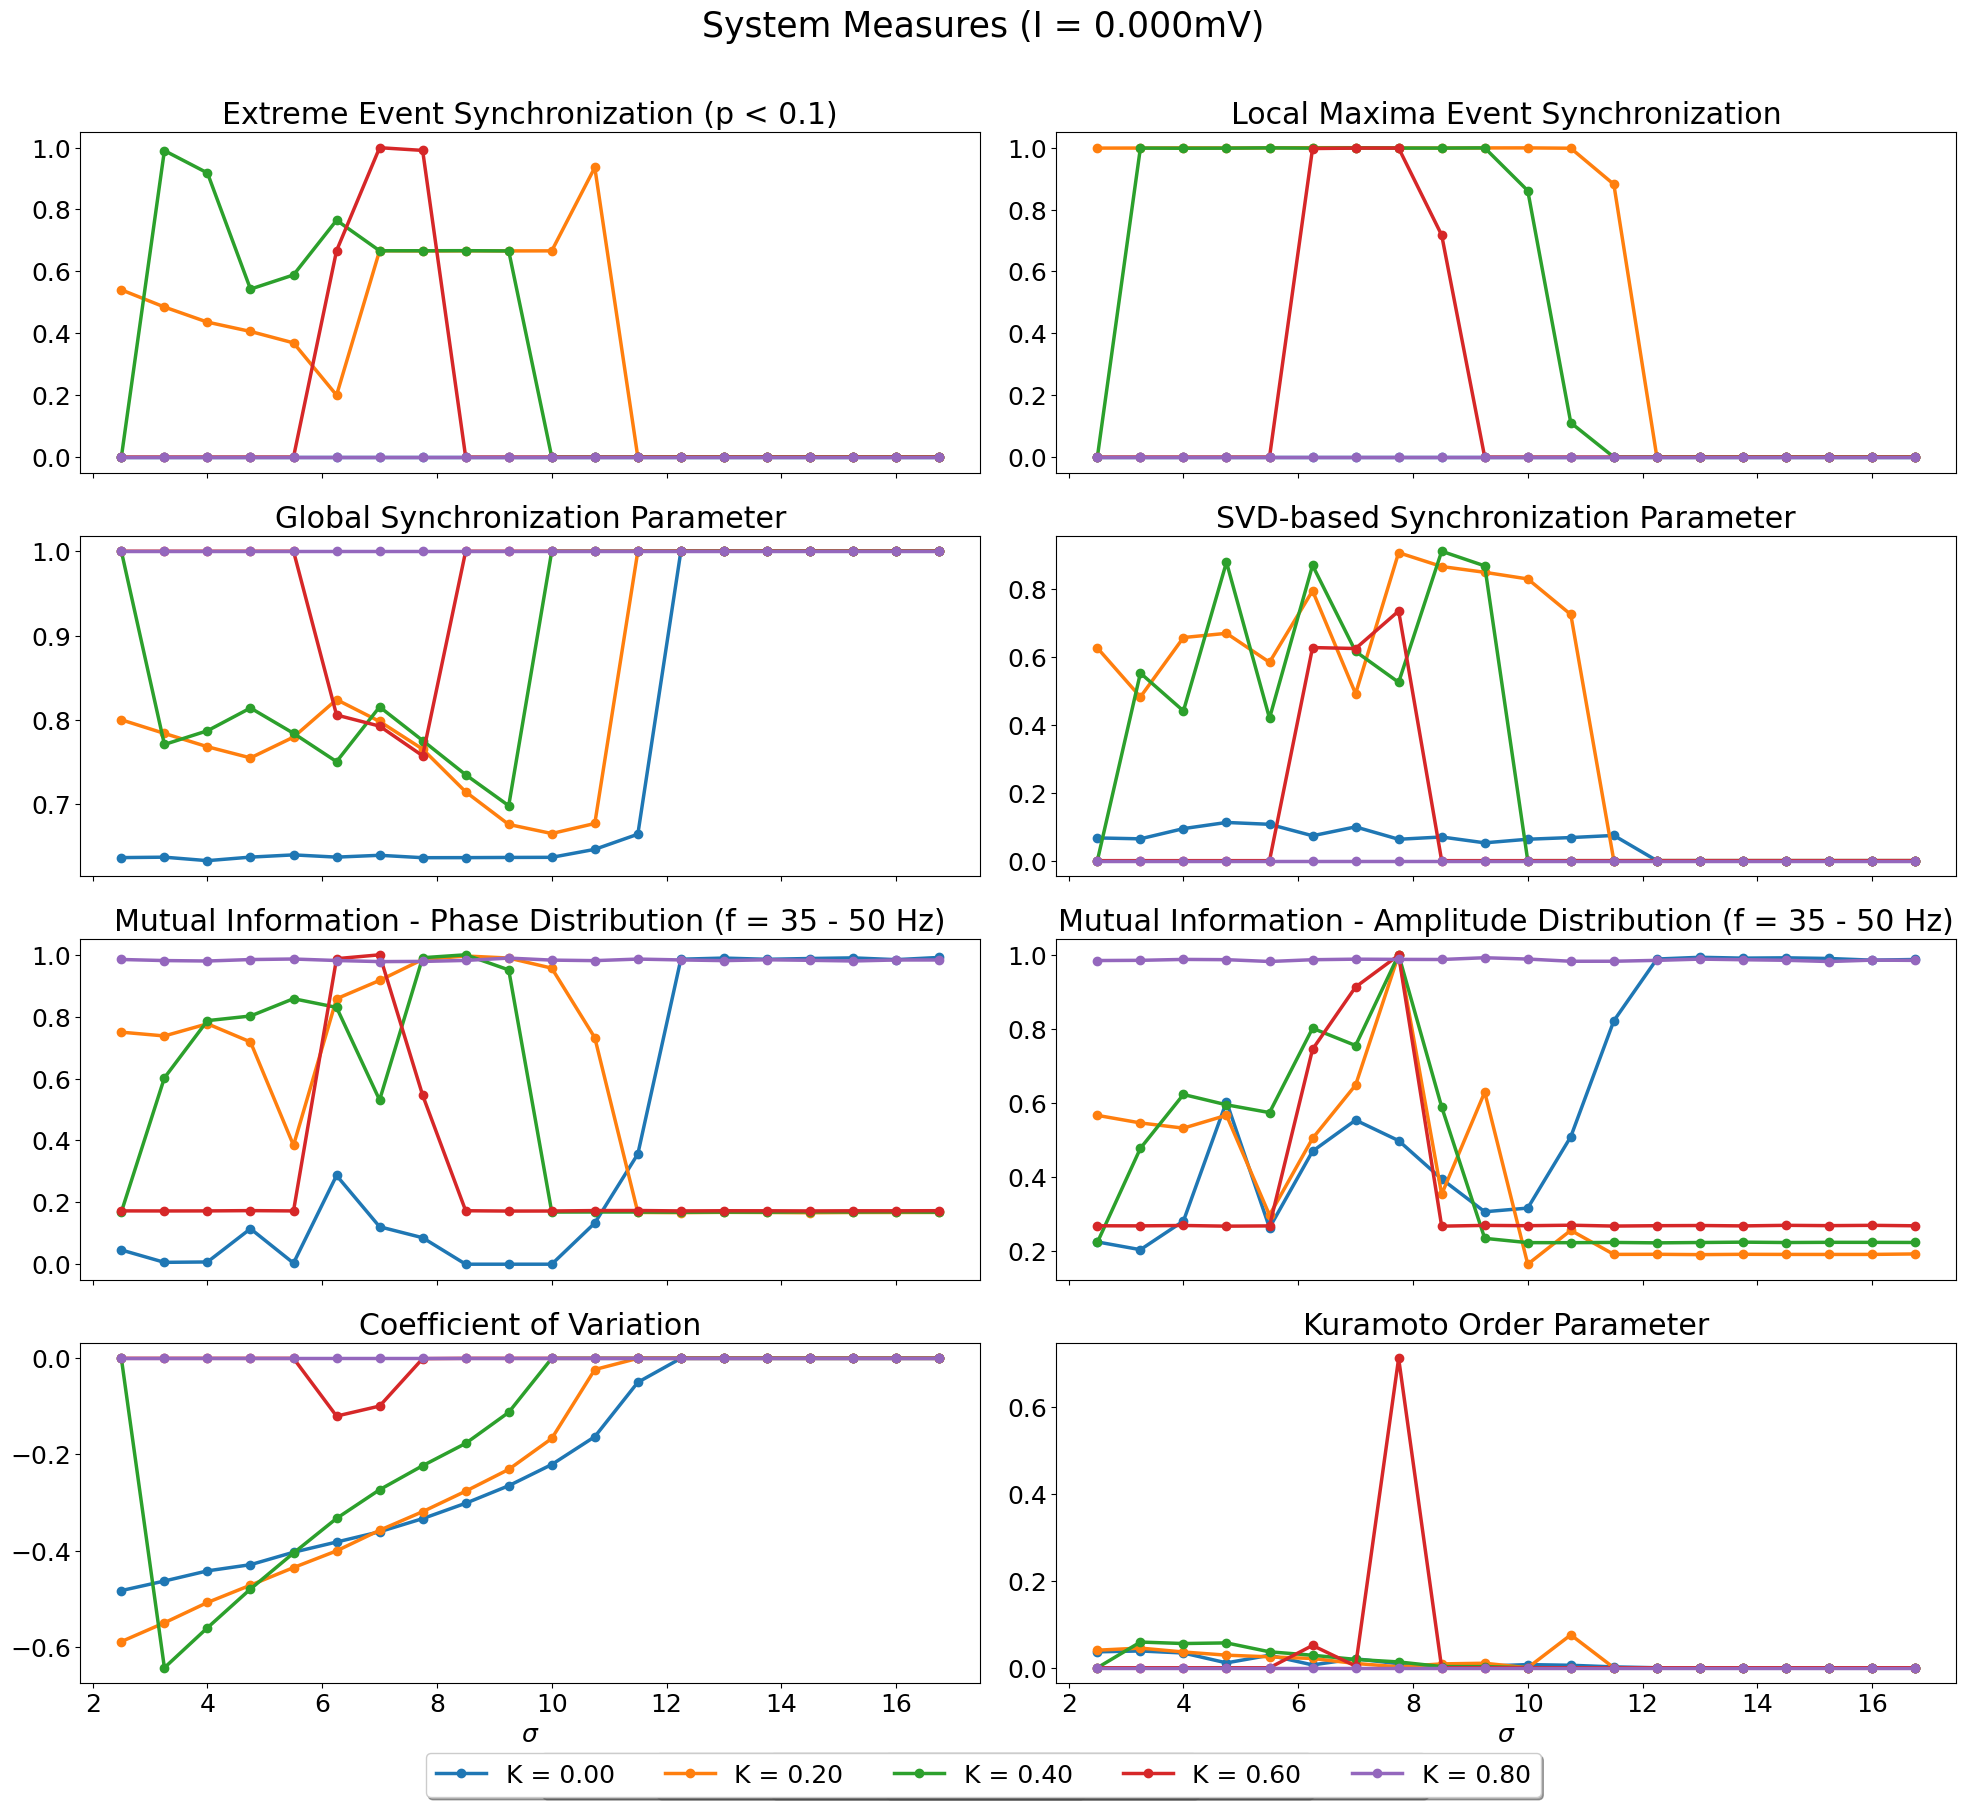

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(20, 18), sharex=True)

for file_name in file_names:
    with open(file_name, 'rb') as _file:
        synchdata = pickle.load(_file)

    split_vals = file_name.split('_')
    K = float(split_vals[2])
    I = float(split_vals[-1][:-6])

    if K < 0:
        continue

    AvalanchSync = synchdata['Avalanch']
    LocalmaxSync = synchdata['Localmax']
    KuramotoOrder = synchdata['Kuramoto']
    GlobalSync = synchdata['GlobalSync']
    SVDSync = synchdata['SVD']
    MI_phase = synchdata['MI_phase']
    MI_amp = synchdata['MI_amp']
    CVStability = synchdata['CV']

    
    AvalanchSyncAvg = np.mean(AvalanchSync, axis=1)
    AvalanchSyncStd = np.std(AvalanchSync, axis=1)

    axes[0, 0].plot(eval_sigma, AvalanchSyncAvg, 'o-', linewidth=2.5, label=f"K = {K:.2f}")
    # axes[0, 0].fill_between(eval_sigma, AvalanchSyncAvg + AvalanchSyncStd, AvalanchSyncAvg - AvalanchSyncStd, color = 'r', alpha = 0.2)
    # axes[0, 0].set_xlabel(r'$\sigma$')
    axes[0, 0].set_title("Extreme Event Synchronization (p < 0.1)")

    LocalmaxSyncAvg = np.mean(LocalmaxSync, axis=1)
    LocalmaxSyncStd = np.std(LocalmaxSync, axis=1)

    axes[0, 1].plot(eval_sigma, LocalmaxSyncAvg, 'o-', linewidth=2.5)
    # axes[0, 1].fill_between(eval_sigma, LocalmaxSyncAvg + LocalmaxSyncStd, LocalmaxSyncAvg - LocalmaxSyncStd, color = 'r', alpha = 0.2)
    # axes[0, 1].set_xlabel(r'$\sigma$')
    axes[0, 1].set_title("Local Maxima Event Synchronization")

    GlobalSyncAvg = np.mean(GlobalSync, axis=1)
    GlobalSyncStd = np.std(GlobalSync, axis=1)

    axes[1, 0].plot(eval_sigma, GlobalSyncAvg, 'o-', linewidth=2.5)
    # axes[1, 0].fill_between(eval_sigma, GlobalSyncAvg + GlobalSyncStd, GlobalSyncAvg - GlobalSyncStd, color = 'r', alpha = 0.2)
    # axes[1, 0].set_xlabel(r'$\sigma$')
    axes[1, 0].set_title("Global Synchronization Parameter")

    SVDSyncAvg = np.mean(SVDSync, axis=1)
    SVDSyncStd = np.std(SVDSync, axis=1)

    axes[1, 1].plot(eval_sigma, SVDSyncAvg, 'o-', linewidth=2.5)
    # axes[1, 1].fill_between(eval_sigma, SVDSyncAvg + SVDSyncStd, SVDSyncAvg - SVDSyncStd, color = 'r', alpha = 0.2)
    # axes[1, 1].set_xlabel(r'$\sigma$')
    axes[1, 1].set_title("SVD-based Synchronization Parameter")

    MI_phase_norm = MI_phase / np.max(MI_phase, axis=0)
    MI_phaseAvg = np.mean(MI_phase_norm, axis=1)
    MI_phaseStd = np.std(MI_phase_norm, axis=1)

    axes[2, 0].plot(eval_sigma, MI_phaseAvg, 'o-', linewidth=2.5)
    # axes[2, 0].fill_between(eval_sigma, MI_phaseAvg + MI_phaseStd, MI_phaseAvg - MI_phaseStd, color = 'r', alpha = 0.2)
    # axes[2, 0].set_xlabel(r'$\sigma$')
    axes[2, 0].set_title("Mutual Information - Phase Distribution (f = 35 - 50 Hz)")

    MI_amp_norm = MI_amp / np.max(MI_amp, axis=0)
    MI_ampAvg = np.mean(MI_amp_norm, axis=1)
    MI_ampStd = np.std(MI_amp_norm, axis=1)


    axes[2, 1].plot(eval_sigma, MI_ampAvg, 'o-', linewidth=2.5)
    # axes[2, 1].fill_between(eval_sigma, MI_ampAvg + MI_ampStd, MI_ampAvg - MI_ampStd, color = 'r', alpha = 0.2)
    # axes[2, 1].set_xlabel(r'$\sigma$')
    axes[2, 1].set_title("Mutual Information - Amplitude Distribution (f = 35 - 50 Hz)")

    CVStabilityAvg = np.mean(CVStability, axis=1)
    CVStabilityStd = np.std(CVStability, axis=1)
    print(round(CVStabilityAvg[-1], 3) == 0.0)

    axes[3, 0].plot(eval_sigma, CVStabilityAvg, 'o-', linewidth=2.5)
    # axes[3, 0].fill_between(eval_sigma, CVStabilityAvg + CVStabilityStd, CVStabilityAvg - CVStabilityStd, color = 'r', alpha = 0.2)
    axes[3, 0].set_xlabel(r'$\sigma$')
    axes[3, 0].set_title("Coefficient of Variation")

    KuramotoOrder[-4] = 0
    KuramotoOrder[-5] = 0
    KuramotoOrderAvg = np.mean(KuramotoOrder, axis=1)
    KuramotoOrderStd = np.std(KuramotoOrder, axis=1)

    axes[3, 1].plot(eval_sigma, KuramotoOrderAvg, 'o-', linewidth=2.5)
    # axes[3, 1].fill_between(eval_sigma, KuramotoOrderAvg + KuramotoOrderStd, KuramotoOrderAvg - KuramotoOrderStd, color = 'r', alpha = 0.2)
    axes[3, 1].set_xlabel(r'$\sigma$')
    axes[3, 1].set_title("Kuramoto Order Parameter")

    fig.suptitle(f"System Measures (I = {I:.3f}mV)\n", fontsize=25)
    fig.tight_layout()
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.02), ncols=6, fancybox=True, shadow=True)

    # plt.savefig(os.path.join(save_dir, f"results_K_{params['K']:.2f}_I_{params['i_e1']:.3f}mV.png"))


In [14]:
import pickle
file_name = './results/fp/scene01/exp-2023-12-15/scene01_data.pkl'

datafile = pickle.load(open(file_name, 'rb'))
type(datafile)

dict

In [20]:
import pandas as pd
import numpy as np
import random

dataframe = pd.DataFrame(datafile)
dataframe.head(10)

,I,K,sigma,ue1,ui1,ue2,ui2,FP_type
0,-15.625,-1.0,2.50,-7.7586,-31.0480,-7.7586,-31.0480,red
1,-15.625,-1.0,2.50,-2.7673,-5.6879,-2.7673,-5.6879,purple
2,-15.625,-1.0,2.50,-12.9679,-31.2500,-2.6571,-4.1608,purple
3,-15.625,-1.0,2.50,-2.6571,-4.1608,-12.9679,-31.2500,purple
4,-15.625,-1.0,2.50,-3.4253,-14.7981,-3.4253,-14.7981,red
5,-15.625,-1.0,2.78,-7.6530,-30.6519,-7.6530,-30.6519,red
6,-15.625,-1.0,2.78,-3.8092,-14.8873,-3.0890,-5.9888,purple
7,-15.625,-1.0,2.78,-3.1046,-6.1934,-3.1046,-6.1934,purple
8,-15.625,-1.0,3.06,-3.4259,-6.4174,-4.3673,-16.5653,purple
9,-15.625,-1.0,3.06,-3.3115,-5.1284,-12.3102,-31.2439,purple


In [21]:
i_values = np.unique(dataframe['I'])
k_values = np.unique(dataframe['K'])

print(i_values)
print(k_values)

[-1.56250000e+01 -1.50000000e+01 -1.43750000e+01 -1.37500000e+01
 -1.31250000e+01 -1.25000000e+01 -1.18750000e+01 -1.12500000e+01
 -1.06250000e+01 -1.00000000e+01 -9.37500000e+00 -8.75000000e+00
 -8.12500000e+00 -7.50000000e+00 -6.87500000e+00 -6.25000000e+00
 -5.62500000e+00 -5.00000000e+00 -4.37500000e+00 -3.75000000e+00
 -3.12500000e+00 -2.50000000e+00 -1.87500000e+00 -1.25000000e+00
 -6.25000000e-01  1.38777878e-14  6.25000000e-01  1.25000000e+00
  1.87500000e+00  2.50000000e+00  3.12500000e+00  3.75000000e+00
  4.37500000e+00  5.00000000e+00  5.62500000e+00  6.25000000e+00
  6.87500000e+00  7.50000000e+00  8.12500000e+00  8.75000000e+00
  9.37500000e+00  1.00000000e+01  1.06250000e+01  1.12500000e+01
  1.18750000e+01  1.25000000e+01  1.31250000e+01  1.37500000e+01
  1.43750000e+01  1.50000000e+01]
[-1.0000000e+00 -9.6000000e-01 -9.2000000e-01 -8.8000000e-01
 -8.4000000e-01 -8.0000000e-01 -7.6000000e-01 -7.2000000e-01
 -6.8000000e-01 -6.4000000e-01 -6.0000000e-01 -5.6000000e-01
 -5

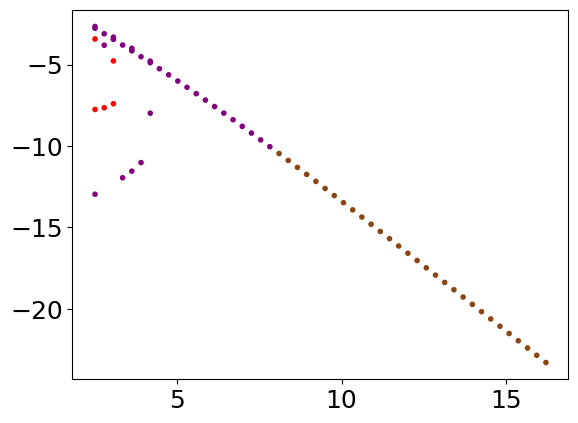

In [52]:
sampledf = dataframe[(dataframe['I'] == i_values[0]) & (dataframe['K'] == k_values[0])]
fp_types_sample = np.unique(sampledf['FP_type'])

plt.scatter(sampledf['sigma'], sampledf['ue1'], marker='.', c = sampledf['FP_type'])

# colors_ = sampledf['FP_type'].to_list()

# for i in range(1, len(colors_) - 1):
#     if colors_[i-1] == colors_[i+1] and colors_[i] != colors_[i-1]:
#          colors_[i] = colors_[i-1]

# sampledf['FP_type'] = colors_

In [54]:
sigma_ = sampledf['sigma'].to_numpy()
ue1 = sampledf['ue1'].to_numpy()
fp_types = sampledf['FP_type'].to_numpy()

In [57]:
ue1_indx = np.argsort(ue1)

In [60]:
sampledf['FP_type'] = fp_types[ue1_indx]
sampledf['ue1'] = ue1[ue1_indx]
sampledf['sigma'] = sigma_[ue1_indx]

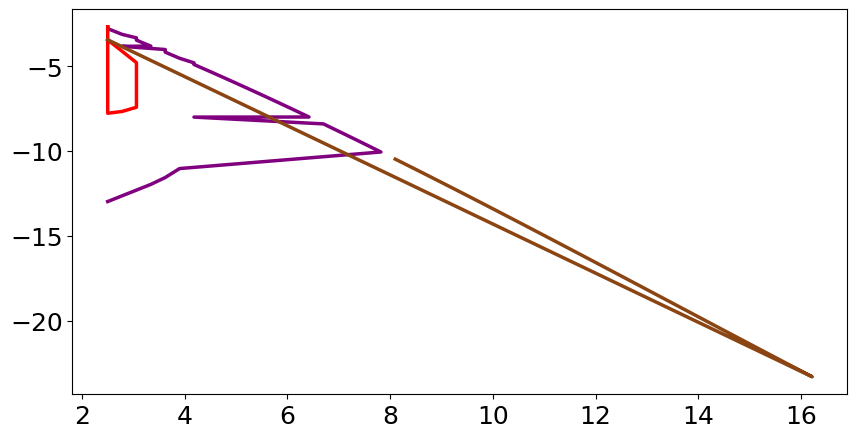

In [61]:
connector_sigma = None
connector_ue1 = None

plt.figure(figsize=(10, 5))
for fp_color in fp_types_sample:
    sigma_ = sampledf['sigma'][sampledf['FP_type'] == fp_color].to_numpy()
    ue1_ = sampledf['ue1'][sampledf['FP_type'] == fp_color].to_numpy()

    if connector_sigma and connector_ue1:
        sigma_ = np.array([connector_sigma] + list(sigma_))
        ue1_ = np.array([connector_ue1] + list(ue1_))
    plt.plot(sigma_, ue1_, fp_color, linewidth=2.5)

    connector_sigma = sigma_[-1]
    connector_ue1 = ue1_[-1]

In [28]:
sampledf

,I,K,sigma,ue1,ui1,ue2,ui2,FP_type
3126,-15.625,0.44,2.50,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3127,-15.625,0.44,2.78,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3128,-15.625,0.44,3.06,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3129,-15.625,0.44,3.34,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3130,-15.625,0.44,3.62,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3131,-15.625,0.44,3.90,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3132,-15.625,0.44,4.18,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3133,-15.625,0.44,4.46,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3134,-15.625,0.44,4.74,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen
3135,-15.625,0.44,5.02,-27.9018,-31.2500,-27.9018,-31.2500,darkgreen


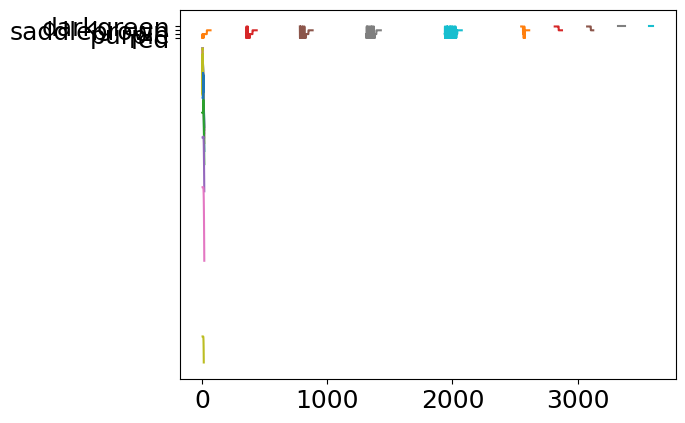

In [17]:
for k_val in Ksample:
    sampledf = dataframe[(dataframe['I'] == -15.625) & (dataframe['K'] == k_val)]

    plt.plot(sampledf['sigma'], sampledf['ue1'], sampledf['FP_type'])

In [18]:
ii_min = dataframe[(dataframe['I'] == -15.625) & (dataframe['K'] == np.unique(dataframe['K'])[40])]
ii_min

,I,K,sigma,ue1,ui1,ue2,ui2,FP_type
3326,-15.625,0.6,2.50,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3327,-15.625,0.6,2.78,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3328,-15.625,0.6,3.06,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3329,-15.625,0.6,3.34,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3330,-15.625,0.6,3.62,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3331,-15.625,0.6,3.90,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3332,-15.625,0.6,4.18,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3333,-15.625,0.6,4.46,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3334,-15.625,0.6,4.74,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen
3335,-15.625,0.6,5.02,-39.0625,-31.2500,-39.0625,-31.2500,darkgreen


In [19]:
import matplotlib.pyplot as plt

darkgreen = i_min[i_min['FP_type'] == 'darkgreen']
brown = i_min[i_min['FP_type'] == 'saddlebrown']

darkgreen2 = ii_min[ii_min['FP_type'] == 'darkgreen']


plt.plot(darkgreen['sigma'], darkgreen['ue1'], 'darkgreen')
plt.plot(brown['sigma'][1:2], brown['ue1'][1:2], 'darkgreen')
plt.plot(brown['sigma'][1:], brown['ue1'][1:], 'saddlebrown')

plt.plot(darkgreen2['sigma'], darkgreen2['ue1'], 'green')




NameError: name 'i_min' is not defined

In [ ]:
import numpy as np
np.unique(datafile['I'])

array([-15.625,   0.   ,  15.625])